# 🩸 Diabetes Classification Metrics

This notebook trains a **Logistic Regression** model on the Kaggle / UCI **Pima Indians Diabetes Dataset** and evaluates it using the 4 core classification parameters:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

## Step 1: Import Libraries

In [1]:
import io
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load the Diabetes Dataset

In [2]:
df = pd.read_csv('diabetes_data.csv')
print(f"✅ Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("Target: 'Outcome' (1 = Has Diabetes, 0 = No Diabetes)")
df.head()

✅ Dataset Loaded: 768 rows, 9 columns
Target: 'Outcome' (1 = Has Diabetes, 0 = No Diabetes)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Train-Test Split & Logistic Regression Training

In [3]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("✅ Logistic Regression model trained successfully!")

Training samples: 614
Testing samples:  154
✅ Logistic Regression model trained successfully!


---
## Step 4: Calculate the 4 Classification Metrics

1. **Accuracy**: Overall fraction of correct predictions
2. **Precision**: Out of all predicted positives, how many are actually positive?
3. **Recall**: Out of all actual positive cases, how many did the model capture?
4. **F1 Score**: Harmonic mean of Precision and Recall

In [4]:
# Calculate evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 55)
print("   📊 DIABETES CLASSIFICATION METRICS")
print("=" * 55)
print(f"   📌 Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   📌 Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   📌 Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   📌 F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 55)

   📊 DIABETES CLASSIFICATION METRICS
   📌 Accuracy  : 0.7532  (75.32%)
   📌 Precision : 0.6491  (64.91%)
   📌 Recall    : 0.6727  (67.27%)
   📌 F1 Score  : 0.6607  (66.07%)


## Step 5: Confusion Matrix & Breakdown

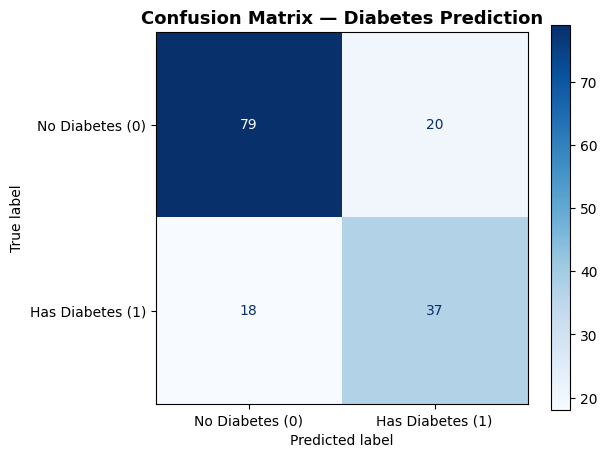

True Negatives  (TN) = 79
False Positives (FP) = 20
False Negatives (FN) = 18
True Positives  (TP) = 37


In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes (0)', 'Has Diabetes (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix — Diabetes Prediction', fontsize=13, fontweight='bold')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN) = {tn}")
print(f"False Positives (FP) = {fp}")
print(f"False Negatives (FN) = {fn}")
print(f"True Positives  (TP) = {tp}")

## Step 6: Classification Report

In [6]:
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Has Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.81      0.80      0.81        99
Has Diabetes       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



## Step 7: Visual Comparison Bar Chart

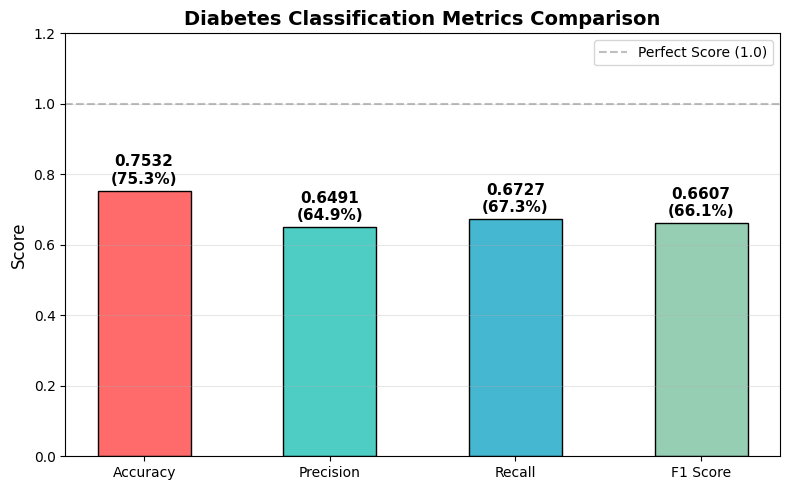

In [7]:
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 1.2)
plt.ylabel('Score', fontsize=12)
plt.title('Diabetes Classification Metrics Comparison', fontsize=14, fontweight='bold')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect Score (1.0)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()